In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, coherent_unitary_error, depolarizing_error
from qiskit.quantum_info import Operator


def get_expectation_z(counts, shots):
    p0 = counts.get('0', 0) / shots
    p1 = counts.get('1', 0) / shots
    return p0 - p1

# define depth for all simulations, d = 1 to 100.
max_depth = 100
depths = range(1, max_depth + 1)

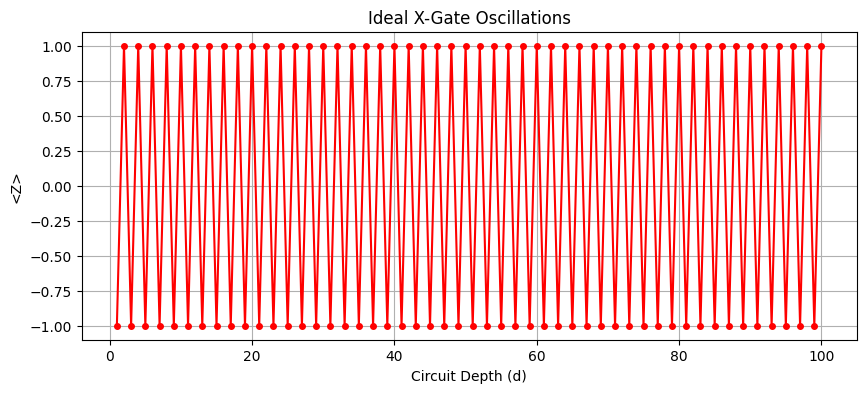

In [ ]:
ideal_results = []
simulator = AerSimulator(method='statevector') # statevector has zero noise

for d in depths:
    qc = QuantumCircuit(1)
    for _ in range(d):
        qc.x(0) #applying x gate d times
    qc.measure_all()
    
    # Run ideal simulation (shots=1 effectively gives exact prob for deterministic)
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    counts = result.get_counts()
    ideal_results.append(get_expectation_z(counts, 1))

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(depths, ideal_results, 'o-', label='Ideal', color='red', markersize=4)
plt.title("Ideal X-Gate Oscillations")
plt.xlabel("Circuit Depth (d)")
plt.ylabel("<Z>")
plt.grid(True)
plt.show()

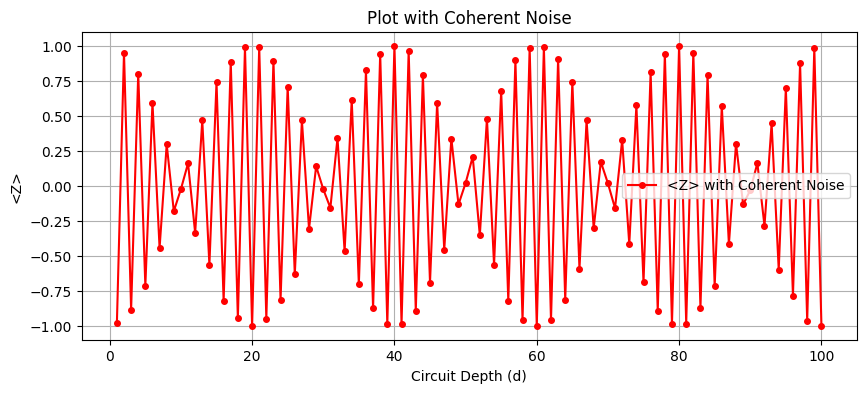

In [ ]:
# We add a small extra rotation e to every gate
e = 0.05 * np.pi 
error_unitary = Operator([[np.cos(e/2), -1j * np.sin(e/2)],
                          [-1j * np.sin(e/2), np.cos(e/2)]])

coherent_noise_model = NoiseModel()
coherent_noise_model.add_all_qubit_quantum_error(coherent_unitary_error(error_unitary), ['x'])

coherent_results = []
simulator = AerSimulator(noise_model=coherent_noise_model)

for d in depths:
    qc = QuantumCircuit(1)
    for _ in range(d):
        qc.x(0)
    qc.measure_all()
    
    # optimization level is set to 0 to keep the effects of all X gates, otherwise transpiling changes the circuit
    
    t_qc = transpile(qc, simulator, optimization_level=0, basis_gates=['x', 'measure'])
    
    result = simulator.run(t_qc, shots=2000).result()
    coherent_results.append(get_expectation_z(result.get_counts(), 2000))


plt.figure(figsize=(10, 4))
plt.plot(depths, coherent_results, 'o-', color='red', markersize=4, label='<Z> with Coherent Noise')
plt.title(f"Plot with Coherent Noise")
plt.xlabel("Circuit Depth (d)")
plt.ylabel("<Z>")
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.legend()
plt.show()

/home/kavish/miniconda3/envs/qiskit-env/lib/python3.13/site-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


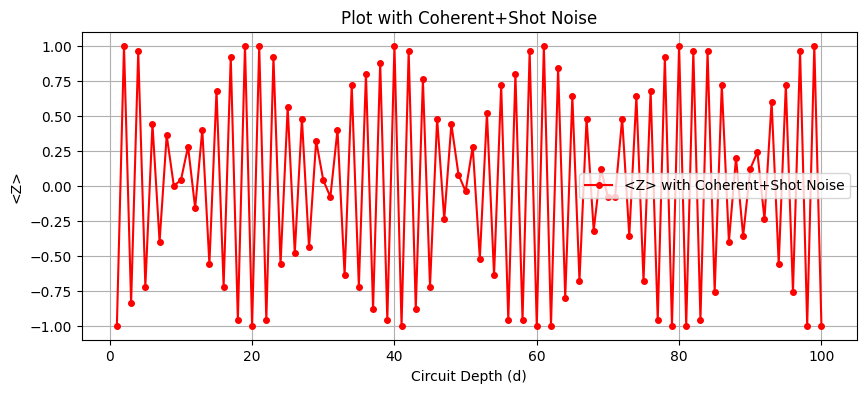

In [16]:

shot_noise_results = []
simulator = AerSimulator(noise_model=coherent_noise_model)

for d in depths:
    qc = QuantumCircuit(1)
    for _ in range(d):
        qc.x(0)
    qc.measure_all()
    
    t_qc = transpile(qc, simulator, optimization_level=0, basis_gates=['x', 'measure'])
    
    result = simulator.run(t_qc, shots=50).result() #we just decreased the number of shots to get shot noise (proportional to 1/sqrt(n))
    shot_noise_results.append(get_expectation_z(result.get_counts(), 50))


plt.figure(figsize=(10, 4))
plt.plot(depths, shot_noise_results, 'o-', color='red', markersize=4, label='<Z> with Coherent+Shot Noise')
plt.title(f"Plot with Coherent+Shot Noise")
plt.xlabel("Circuit Depth (d)")
plt.ylabel("<Z>")
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.legend()
plt.show()

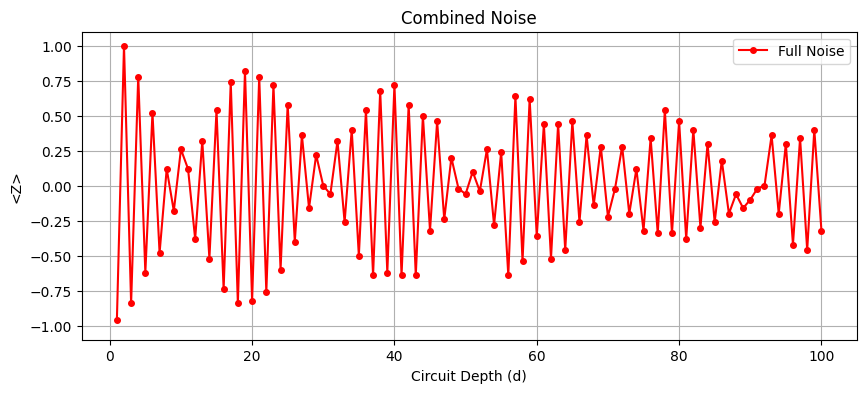

In [22]:
# Parameters
p_depol = 0.01  # 1% probability of randomizing the state (Incoherent error)


coherent_err = coherent_unitary_error(error_unitary)

incoherent_err = depolarizing_error(p_depol, 1)

total_error = coherent_err.compose(incoherent_err)

full_noise_model = NoiseModel()
full_noise_model.add_all_qubit_quantum_error(total_error, ['x'])


results = []
simulator_full = AerSimulator(noise_model=full_noise_model)

for d in depths:
    qc = QuantumCircuit(1)
    for _ in range(d):
        qc.x(0)
    qc.measure_all()

    t_qc = transpile(qc, simulator_full, optimization_level=0, basis_gates=['x', 'measure'])
    
    result = simulator_full.run(t_qc, shots=100).result()
    results.append(get_expectation_z(result.get_counts(), 100))

plt.figure(figsize=(10, 4))
plt.plot(depths, results, 'o-', color='red', markersize=4, label='Full Noise')
plt.title(f"Combined Noise")
plt.xlabel("Circuit Depth (d)")
plt.ylabel("<Z>")
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.legend()
plt.show()